<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/Representation%20Learning/Variational_Auto_Encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Subset,DataLoader,random_split
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [76]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Model Architecture

## Encoder

In [77]:
class Encoder(nn.Module):
  def __init__(self, latent_dim=10, in_channels=3):
    super(Encoder, self).__init__()
    self.convLayers = nn.Sequential(
        nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
        nn.ReLU()
    )
    self.flatten = nn.Flatten()
    self.fc_mu = nn.Linear(256*4*4, latent_dim)
    self.fc_logvar = nn.Linear(256*4*4, latent_dim)

  def forward(self, x):
    x = self.convLayers(x)
    x = self.flatten(x)
    mu = self.fc_mu(x)
    logvar = self.fc_logvar(x)
    return mu, logvar

## Reparameterization

In [78]:
def reparameterize(mu, sigma):
  eps = torch.randn_like(sigma)
  return mu + eps*sigma

## Decoder

In [79]:
class Decoder(nn.Module):
  def __init__(self, latent_dim=10, out_channels=3):
    super(Decoder, self).__init__()
    self.fc = nn.Linear(latent_dim, 256*4*4)
    self.convLayers = nn.Sequential(
        nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
        nn.ReLU(),
        nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
        nn.ReLU(),
        nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
        nn.ReLU(),
        nn.ConvTranspose2d(32, out_channels, kernel_size=3, stride=1, padding=1)
    )

  def forward(self, x):
    x = self.fc(x)
    x = x.view(-1, 256, 4, 4)
    x = self.convLayers(x)
    return x

In [80]:
class BernoulliDecoder(Decoder):
    def forward(self, x):
        return torch.sigmoid(super().forward(x))

In [81]:
class GaussianDecoder(Decoder):
    def forward(self, x):
        return super().forward(x)

## VAE

In [82]:
class VAE(nn.Module):
  def __init__(self, latent_dim=10, in_channels=3, decoder_type='gaussian'):
    super(VAE, self).__init__()
    self.decoder_type = decoder_type
    self.enc = Encoder(latent_dim, in_channels)
    if decoder_type == 'gaussian':
      self.dec = GaussianDecoder(latent_dim, in_channels)
    else:
      self.dec = BernoulliDecoder(latent_dim, in_channels)

  def encoder(self, x):
    mu, logvar = self.enc(x)
    sigma=torch.exp(0.5*logvar)
    z = reparameterize(mu, sigma)
    return mu, z

  def decoder(self, z):
    x = self.dec(z)
    return x

  def forward(self, x, kl_weight=1.0):
    mu, logvar=self.enc(x)
    sigma=torch.exp(0.5*logvar)
    z=reparameterize(mu, sigma)
    y=self.decoder(z)

    batch_size=x.shape[0]
    x_flat=x.view(batch_size, -1)
    y_flat=y.view(batch_size, -1)

    if self.decoder_type== 'gaussian':
      L1=F.mse_loss(y_flat, x_flat,reduction='sum')
    else:
      L1=F.binary_cross_entropy(y_flat, x_flat, reduction='sum')

    L2=-0.5*torch.sum(1+logvar - mu**2 - logvar.exp())

    return (L1 + kl_weight * L2)/batch_size

# Test (MNIST)

In [83]:
%%script echo skip

epochs=100
start_epoch=0
learning_rate=1e-3
batch_size=100
patience = 5
device='cuda' if torch.cuda.is_available() else 'cpu'

skip


ToTensor가 0~1값으로 고정

Lambda로 이진화

In [84]:
%%script echo skip

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float())
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#블로그 리뷰용 시드 고정
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(train_dataset, [50000, 10000], generator=generator)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

skip


In [85]:
%%script echo skip

model=VAE(latent_dim=10, in_channels=1, decoder_type='bernoulli').to(device)
optimizer=optim.Adam(model.parameters(), lr=learning_rate)
scheduler=ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

skip


In [86]:
%%script echo skip
best_loss=float('inf')
no_improve=0
train_loss_list=[]
val_loss_list=[]

skip


In [87]:
%%script echo skip


path = f'/content/drive/MyDrive/vae_MNIST.pth'
if os.path.exists(path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    train_loss_list = checkpoint['train_loss_list']
    val_loss_list = checkpoint['val_loss_list']
    best_loss = checkpoint['best_loss']
    start_epoch = checkpoint['epoch']+1

skip


In [88]:
%%script echo skip

for epoch in tqdm(range(start_epoch, epochs), desc="Epoch"):

    train_loss = 0.0
    val_loss = 0.0

    model.train()
    for x, t in tqdm(train_loader, desc="Iteration", leave=False):
        x, t = x.to(device), t.to(device)
        optimizer.zero_grad()
        loss = model(x)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        for x, t in val_loader:
            x, t = x.to(device), t.to(device)
            val_loss += model(x).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        no_improve = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_loss': best_loss,
            'train_loss_list': train_loss_list,
            'val_loss_list': val_loss_list,
            'epoch': epoch
        }, f'/content/drive/MyDrive/vae_CIFAR.pth')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early Stopping at Epoch {epoch+1}")
            break

    print(f'Epoch {epoch+1} | Loss: {train_loss_list[-1]:.4f} | Val: {val_loss_list[-1]:.4f}')

skip


In [89]:
%%script echo skip

plt.plot(train_loss_list, label='train')
plt.plot(val_loss_list, label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

skip


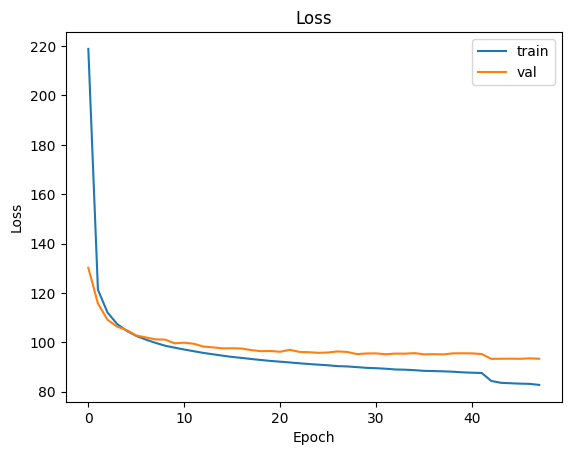

In [90]:
%%script echo skip

test_loss=0.0

means = {i: [] for i in range(10)}
latents = {i: [] for i in range(10)}

model.eval()
with torch.no_grad():
    for x, t in test_loader:
        x, t = x.to(device), t.to(device)
        loss = model(x)
        test_loss += loss.item()

        mu,latent=model.encoder(x)
        for i in range(len(t)):
            label = t[i].item()
            means[label].append(mu[i].cpu().numpy())
            latents[label].append(latent[i].cpu().numpy())


test_loss /= len(test_loader)
print(f'Test Loss: {test_loss:.4f}')

skip


numpy로 옮김

In [91]:
%%script echo skip

means_np = {k: np.array(v) for k, v in means.items()}
latents_np = {k: np.array(v) for k, v in latents.items()}

skip


In [92]:
%%script echo skip

from sklearn.manifold import TSNE

n_samples = 200

all_mu = np.concatenate([means_np[i][:n_samples] for i in range(10)])
all_latents = np.concatenate([latents_np[i][:n_samples] for i in range(10)])

all_labels = np.concatenate([[i]*n_samples for i in range(10)])

tsne = TSNE(n_components=2, random_state=42)
embedded_means = tsne.fit_transform(all_mu)
embedded_latents = tsne.fit_transform(all_latents)

skip


In [93]:
%%script echo skip

import matplotlib.patheffects as pe

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i in range(10):
    mask = all_labels == i
    axes[0].scatter(embedded_means[mask, 0], embedded_means[mask, 1], label=str(i), s=2)
    axes[1].scatter(embedded_latents[mask, 0], embedded_latents[mask, 1], label=str(i), s=2)

    cx = embedded_means[mask, 0].mean()
    cy = embedded_means[mask, 1].mean()
    axes[0].annotate(str(i), (cx, cy), fontsize=12, fontweight='bold', ha='center',
    path_effects=[pe.withStroke(linewidth=3, foreground='white')])

    cx = embedded_latents[mask, 0].mean()
    cy = embedded_latents[mask, 1].mean()
    axes[1].annotate(str(i), (cx, cy), fontsize=12, fontweight='bold', ha='center',
    path_effects=[pe.withStroke(linewidth=3, foreground='white')])

axes[0].set_title('Mean Space')
axes[1].set_title('Latent Space')

#axes[0].legend()
#for handle in axes[0].legend().legend_handles:
    #handle.set_sizes([30])
axes[1].legend()

plt.show()


skip


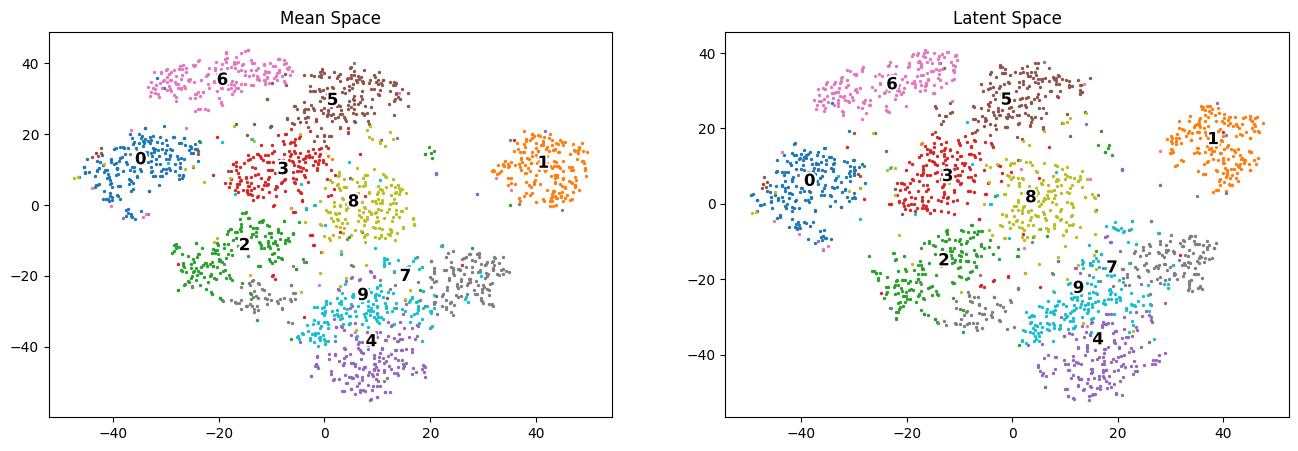

In [94]:
%%script echo skip

mean_embedded = []

all_class_means = np.array([latents_np[i].mean(axis=0) for i in range(10)])

# 기존 데이터에 평균점 붙여서 t-SNE 재실행
combined = np.concatenate([all_latents, all_class_means])
tsne2 = TSNE(n_components=2, random_state=42)
combined_embedded = tsne2.fit_transform(combined)

embedded_latents2 = combined_embedded[:-10]
embedded_class_means = combined_embedded[-10:]

skip


In [95]:
%%script echo skip
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(2, 6,width_ratios=[1,1,1,1,1,5])

# 왼쪽: 2x5 이미지 그리드
img_axes = [[fig.add_subplot(gs[r, c]) for c in range(5)] for r in range(2)]

# 오른쪽: latent space scatter
ax_latent = fig.add_subplot(gs[:, 5])

with torch.no_grad():
    for i in range(10):
        mean_z = torch.tensor(latents_np[i]).mean(axis=0).float().to(device)
        img = model.decoder(mean_z.unsqueeze(0)).view(32, 32).cpu()

        ax = img_axes[i//5][i%5]
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(str(i))
        ax.axis('off')

for i in range(10):
    mask = all_labels == i
    ax_latent.scatter(embedded_latents2[mask, 0], embedded_latents2[mask, 1], s=5, label=str(i))

for i in range(10):
    ax_latent.scatter(embedded_class_means[i, 0], embedded_class_means[i, 1],
                     s=200, marker='*', c='black', zorder=5)


ax_latent.set_title('Latent Space')
legend=ax_latent.legend()
for handle in legend.legend_handles:
    handle.set_sizes([30])
plt.suptitle('Mean Latent Images & Latent Space')
plt.tight_layout()
plt.show()

skip


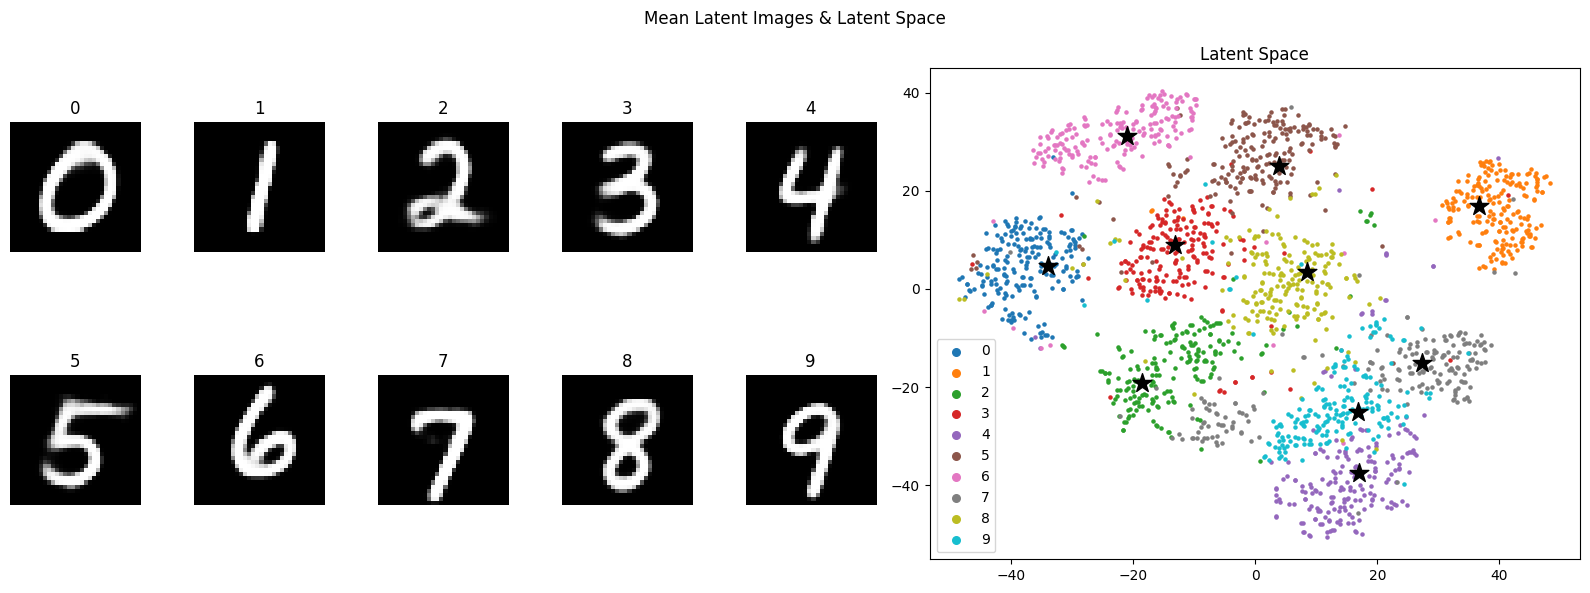

# Test2 (CIFAR10)

In [96]:
#%%script echo skip

epochs=100
start_epoch=0
learning_rate=1e-3
batch_size=100
patience = 5
device='cuda' if torch.cuda.is_available() else 'cpu'

In [97]:
#%%script echo skip
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(root='/data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='/data', train=False, download=True, transform=transform)

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(train_dataset, [40000, 10000], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [98]:
#%%script echo skip

model=VAE(latent_dim=64).to(device)
optimizer=optim.Adam(model.parameters(), lr=learning_rate)
scheduler=ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

In [99]:
#%%script echo skip
best_loss=float('inf')
no_improve=0
train_loss_list=[]
val_loss_list=[]

In [100]:
%%script echo skip


path = f'/content/drive/MyDrive/vae_CIFAR.pth'
if os.path.exists(path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    train_loss_list = checkpoint['train_loss_list']
    val_loss_list = checkpoint['val_loss_list']
    best_loss = checkpoint['best_loss']
    start_epoch = checkpoint['epoch']+1

skip


In [101]:
#%%script echo skip

annealing_epochs=20

for epoch in tqdm(range(start_epoch, epochs), desc="Epoch"):

    kl_weight = min(1.0, epoch / annealing_epochs)

    train_loss = 0.0
    val_loss = 0.0

    model.train()
    for x, t in tqdm(train_loader, desc="Iteration", leave=False):
        x, t = x.to(device), t.to(device)
        optimizer.zero_grad()
        loss = model(x,kl_weight=kl_weight)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        for x, t in val_loader:
            x, t = x.to(device), t.to(device)
            val_loss += model(x).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        no_improve = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_loss': best_loss,
            'train_loss_list': train_loss_list,
            'val_loss_list': val_loss_list,
            'epoch': epoch
        }, f'/content/drive/MyDrive/vae_CIFAR.pth')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early Stopping at Epoch {epoch+1}")
            break

    print(f'Epoch {epoch+1} | Loss: {train_loss_list[-1]:.4f} | Val: {val_loss_list[-1]:.4f}')

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Iteration:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 1 | Loss: 101.8805 | Val: 496.6552


Iteration:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 2 | Loss: 53.7014 | Val: 168.0465


...

Epoch 52 | Loss: 72.2641 | Val: 73.2816


Iteration:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 53 | Loss: 72.2540 | Val: 73.3402


Iteration:   0%|          | 0/400 [00:00<?, ?it/s]

Early Stopping at Epoch 54


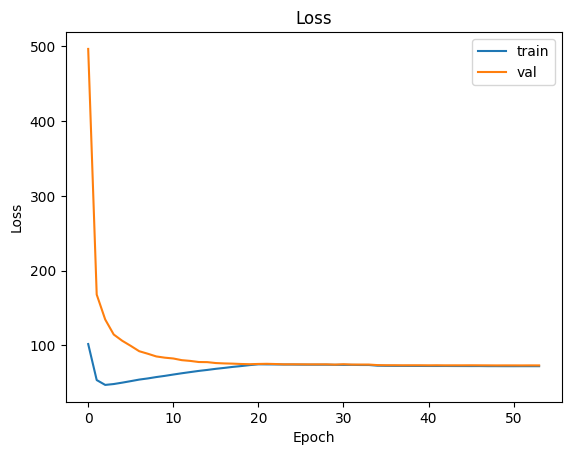

In [102]:
#%%script echo skip

plt.plot(train_loss_list, label='train')
plt.plot(val_loss_list, label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [103]:
#%%script echo skip

test_loss=0.0

means = {i: [] for i in range(10)}
latents = {i: [] for i in range(10)}

model.eval()
with torch.no_grad():
    for x, t in test_loader:
        x, t = x.to(device), t.to(device)
        loss = model(x)
        test_loss += loss.item()

        mu,latent=model.encoder(x)
        for i in range(len(t)):
            label = t[i].item()
            means[label].append(mu[i].cpu().numpy())
            latents[label].append(latent[i].cpu().numpy())


test_loss /= len(test_loader)
print(f'Test Loss: {test_loss:.4f}')

Test Loss: 73.1379


In [104]:
#%%script echo skip

means_np = {k: np.array(v) for k, v in means.items()}
latents_np = {k: np.array(v) for k, v in latents.items()}

In [105]:
#%%script echo skip

from sklearn.manifold import TSNE

n_samples = 200

all_mu = np.concatenate([means_np[i][:n_samples] for i in range(10)])
all_latents = np.concatenate([latents_np[i][:n_samples] for i in range(10)])

all_labels = np.concatenate([[i]*n_samples for i in range(10)])

tsne = TSNE(n_components=2, random_state=42)
embedded_means = tsne.fit_transform(all_mu)
embedded_latents = tsne.fit_transform(all_latents)

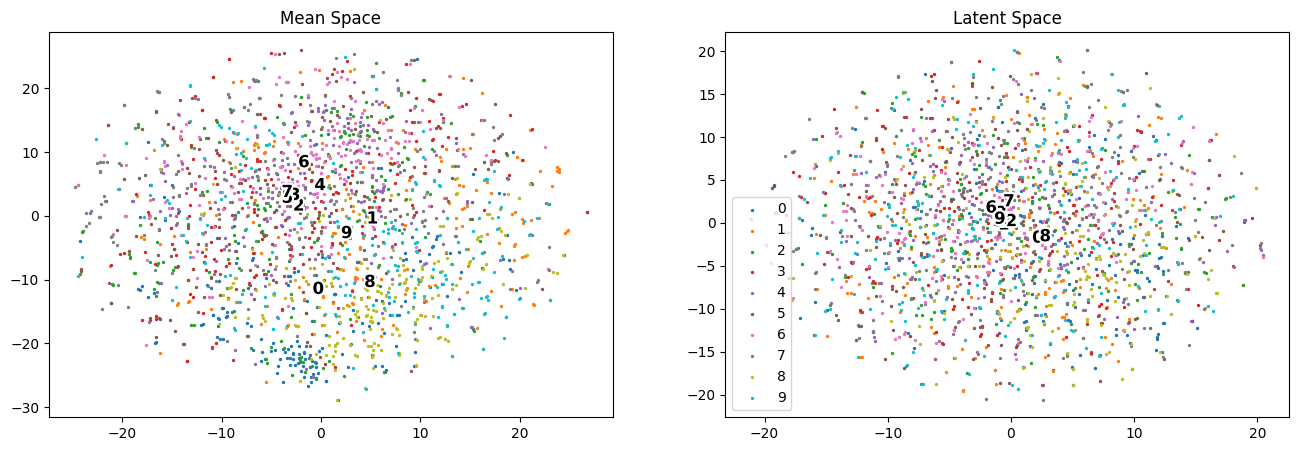

In [106]:
#%%script echo skip

import matplotlib.patheffects as pe

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i in range(10):
    mask = all_labels == i
    axes[0].scatter(embedded_means[mask, 0], embedded_means[mask, 1], label=str(i), s=2)
    axes[1].scatter(embedded_latents[mask, 0], embedded_latents[mask, 1], label=str(i), s=2)

    cx = embedded_means[mask, 0].mean()
    cy = embedded_means[mask, 1].mean()
    axes[0].annotate(str(i), (cx, cy), fontsize=12, fontweight='bold', ha='center',
    path_effects=[pe.withStroke(linewidth=3, foreground='white')])

    cx = embedded_latents[mask, 0].mean()
    cy = embedded_latents[mask, 1].mean()
    axes[1].annotate(str(i), (cx, cy), fontsize=12, fontweight='bold', ha='center',
    path_effects=[pe.withStroke(linewidth=3, foreground='white')])

axes[0].set_title('Mean Space')
axes[1].set_title('Latent Space')

#axes[0].legend()
#for handle in axes[0].legend().legend_handles:
    #handle.set_sizes([30])
axes[1].legend()

plt.show()


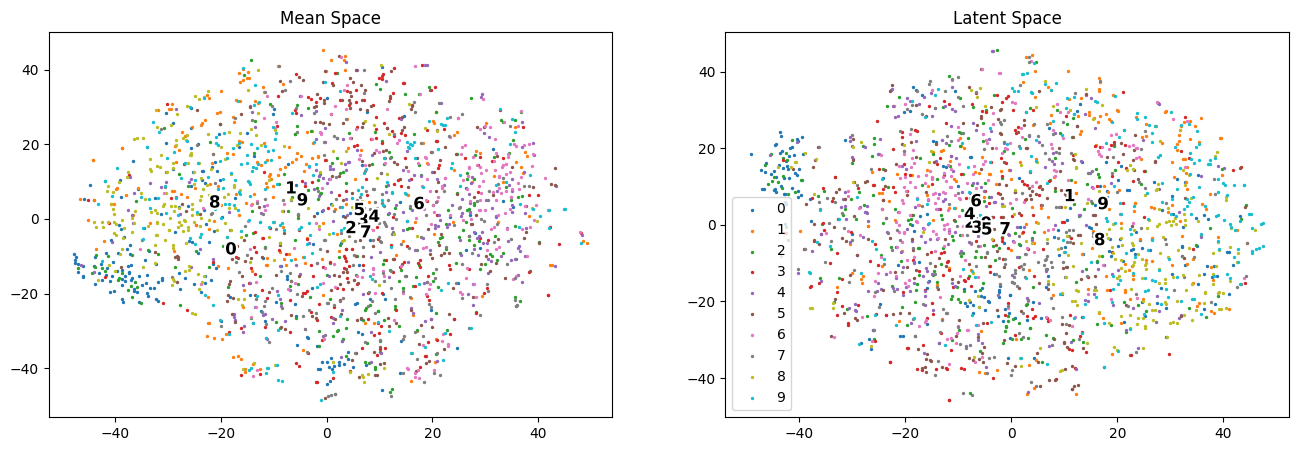

KL Annealing 및 latent 차원 확장 이후

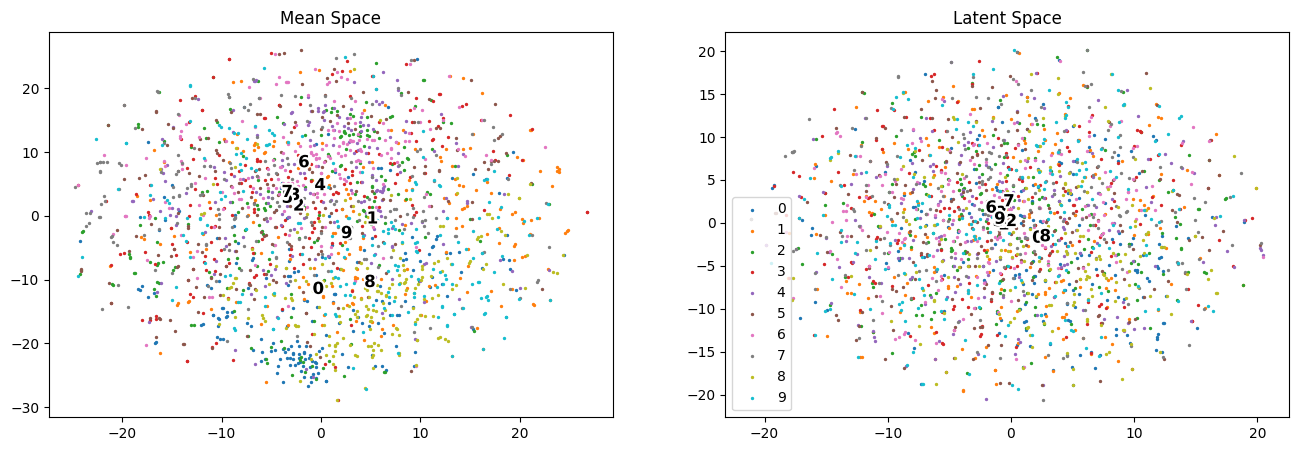

In [107]:
#%%script echo skip

mean_embedded = []

all_class_means = np.array([latents_np[i].mean(axis=0) for i in range(10)])

# 기존 데이터에 평균점 붙여서 t-SNE 재실행
combined = np.concatenate([all_latents, all_class_means])
tsne2 = TSNE(n_components=2, random_state=42)
combined_embedded = tsne2.fit_transform(combined)

embedded_latents2 = combined_embedded[:-10]
embedded_class_means = combined_embedded[-10:]

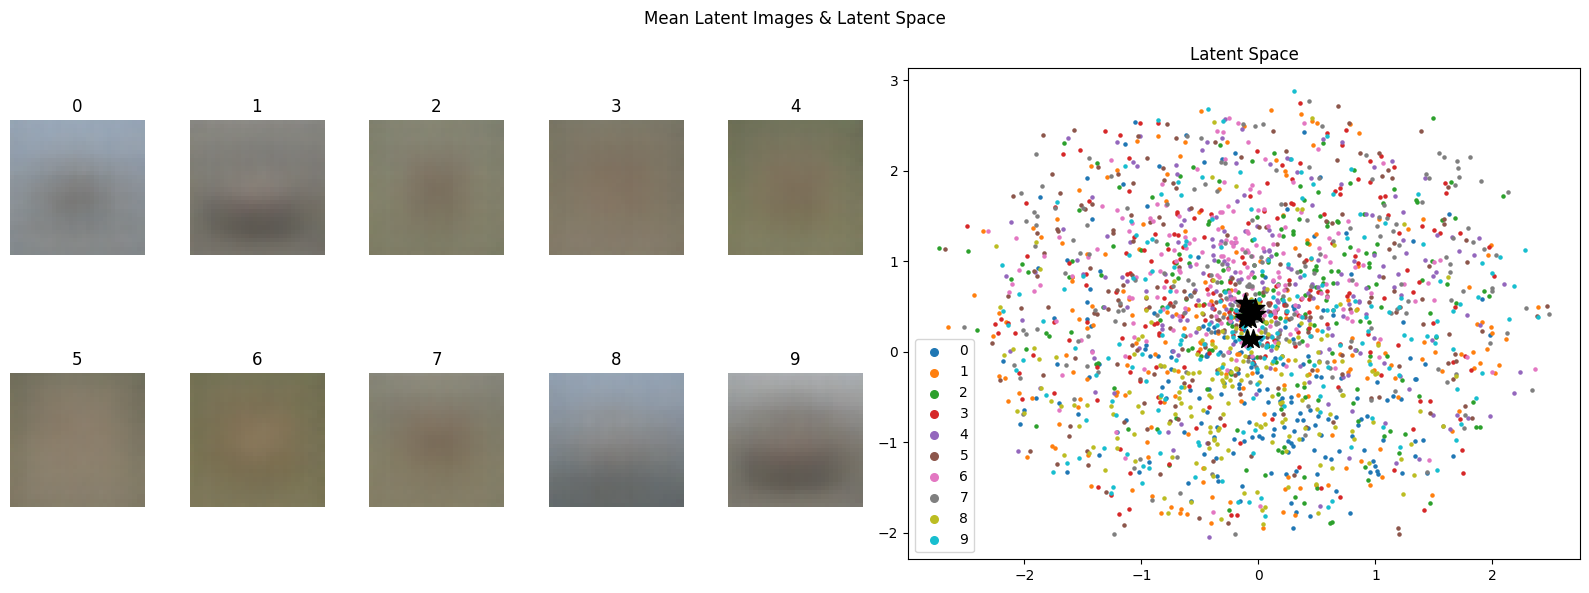

In [108]:
#%%script echo skip
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(2, 6,width_ratios=[1,1,1,1,1,5])

# 왼쪽: 2x5 이미지 그리드
img_axes = [[fig.add_subplot(gs[r, c]) for c in range(5)] for r in range(2)]

# 오른쪽: latent space scatter
ax_latent = fig.add_subplot(gs[:, 5])

with torch.no_grad():
    for i in range(10):
        mean_z = torch.tensor(latents_np[i]).mean(axis=0).float().to(device)
        img = model.decoder(mean_z.unsqueeze(0)).view(3,32, 32).cpu()

        ax = img_axes[i//5][i%5]
        ax.imshow(img.permute(1, 2, 0).squeeze())
        ax.set_title(str(i))
        ax.axis('off')

for i in range(10):
    mask = all_labels == i
    ax_latent.scatter(embedded_latents2[mask, 0], embedded_latents2[mask, 1], s=5, label=str(i))

for i in range(10):
    ax_latent.scatter(embedded_class_means[i, 0], embedded_class_means[i, 1],
                     s=200, marker='*', c='black', zorder=5)


ax_latent.set_title('Latent Space')
legend=ax_latent.legend()
for handle in legend.legend_handles:
    handle.set_sizes([30])
plt.suptitle('Mean Latent Images & Latent Space')
plt.tight_layout()
plt.show()

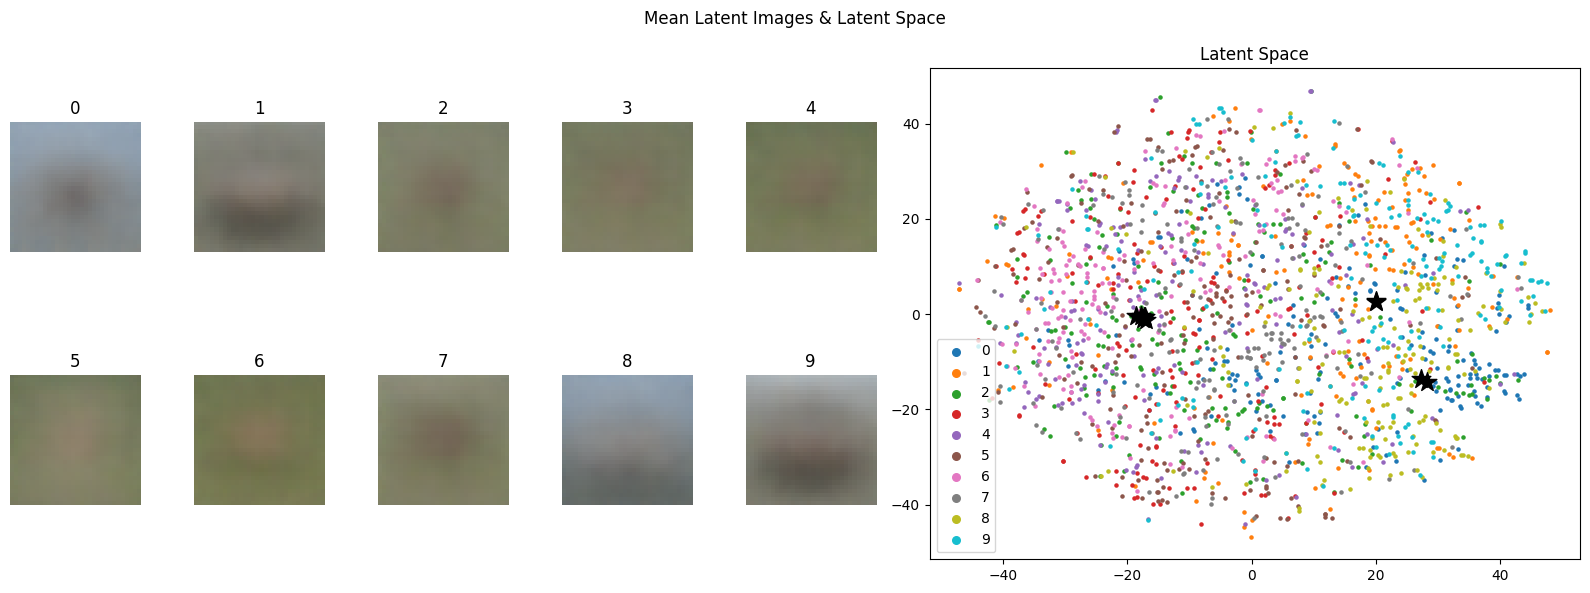